# 04 · Results, Analysis & Conclusions
Report sections: *Results* + *Analysis*. Loads the per-notebook result CSVs (no model refit) for the comparison, then runs the dimensionality-reduction ablation.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.baselines import PCA, GaussianClassifier, KNNClassifier
from src.metrics import accuracy, collapse_winner
from src.plotting import save_fig, plot_sweep

## 1. Consolidated comparison
Baselines (02) + SAMME (03) + naive + market, on the original-corner test.

In [2]:
base = pd.read_csv('../report/results_baselines.csv', index_col='model')
ext = pd.read_csv('../report/results_extension.csv', index_col='model')
table = pd.concat([ext, base])
ds = build_dataset(seed=0)
ar = (collapse_winner(ds.y_test.values) == 'Red').mean()
print(f'always-red winner = {ar:.3f}   coin-flip = 0.500   market log-loss = 1.551')
table.round(3)

always-red winner = 0.562   coin-flip = 0.500   market log-loss = 1.551


,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,logloss_mean
model,,,,,,
SAMME,0.349,0.012,0.633,0.016,0.515,1.663
LDA,0.343,0.004,0.626,0.004,0.516,1.592
QDA,0.230,0.018,0.567,0.029,0.371,3.134
kNN (k=15),0.282,0.004,0.550,0.006,0.497,3.642
majority,0.266,0.025,0.521,0.059,0.514,1.702


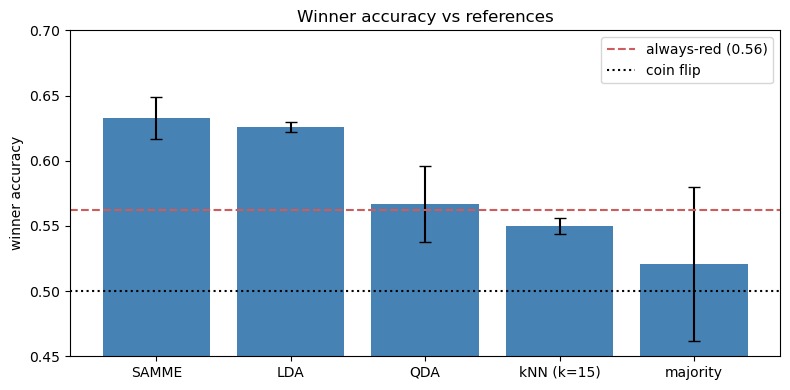

In [3]:
order = [m for m in ['SAMME','LDA','QDA','kNN (k=15)','majority'] if m in table.index]
means = table.loc[order,'winner_mean']; stds = table.loc[order,'winner_std'].fillna(0)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(order, means, yerr=stds, capsize=4, color='steelblue')
ax.axhline(ar, ls='--', c='indianred', label=f'always-red ({ar:.2f})')
ax.axhline(0.5, ls=':', c='k', label='coin flip')
ax.set_ylabel('winner accuracy'); ax.set_ylim(0.45,0.7); ax.legend(); ax.set_title('Winner accuracy vs references')
plt.tight_layout(); save_fig('model_comparison'); plt.show()

## 2. Dimensionality-reduction ablation (E3)
Does PCA rescue QDA / kNN, which struggle in ~114 dimensions? Scree curve, then winner accuracy vs number of components.

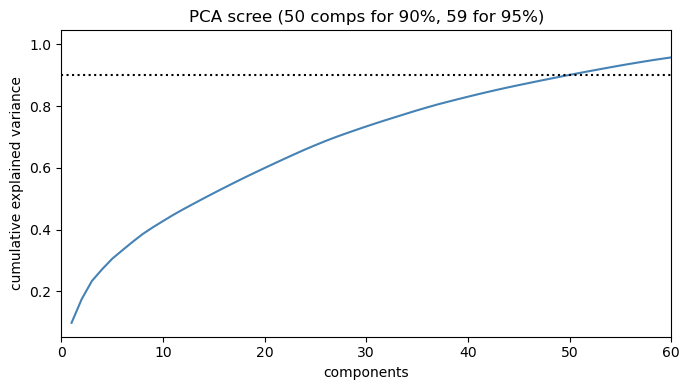

50 components explain 90% of variance, 59 explain 95%


In [4]:
Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
ywin = collapse_winner(yte)
pca = PCA().fit(Xtr)
cum = np.cumsum(pca.explained_variance_ratio_)
d90 = int(np.argmax(cum >= 0.90)) + 1; d95 = int(np.argmax(cum >= 0.95)) + 1
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(cum)+1), cum, color='steelblue'); ax.axhline(0.9, ls=':', c='k')
ax.set_xlabel('components'); ax.set_ylabel('cumulative explained variance'); ax.set_xlim(0,60)
ax.set_title(f'PCA scree ({d90} comps for 90%, {d95} for 95%)')
plt.tight_layout(); save_fig('pca_scree'); plt.show()
print(f'{d90} components explain 90% of variance, {d95} explain 95%')

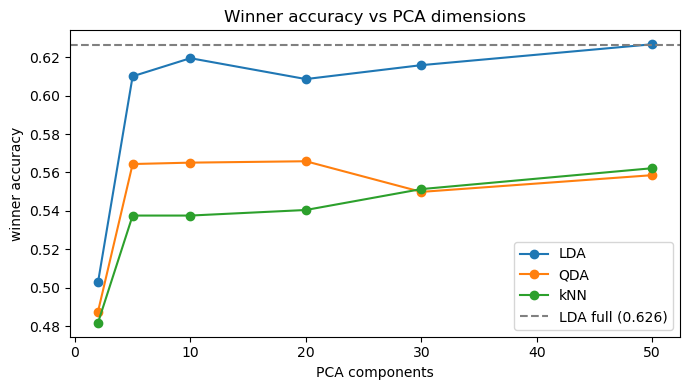

LDA: best PCA winner-acc = 0.627 at d=50 (full-feature was QDA 0.567 / kNN 0.550)
QDA: best PCA winner-acc = 0.566 at d=20 (full-feature was QDA 0.567 / kNN 0.550)
kNN: best PCA winner-acc = 0.562 at d=50 (full-feature was QDA 0.567 / kNN 0.550)


In [5]:
dims = [2, 5, 10, 20, 30, 50]
specs = {'LDA': lambda: GaussianClassifier('lda'),
         'QDA': lambda: GaussianClassifier('qda', reg=1e-3),
         'kNN': lambda: KNNClassifier(k=15)}
curves = {n: [] for n in specs}
for d in dims:
    p = PCA(n_components=d).fit(Xtr)
    Ztr, Zte = p.transform(Xtr), p.transform(Xte)
    for n, make in specs.items():
        m = make().fit(Ztr, ytr)
        curves[n].append(accuracy(ywin, collapse_winner(m.predict(Zte))))
fig, ax = plt.subplots(figsize=(7,4))
for n in specs: ax.plot(dims, curves[n], marker='o', label=n)
ax.axhline(0.626, ls='--', c='grey', label='LDA full (0.626)')
ax.set_xlabel('PCA components'); ax.set_ylabel('winner accuracy'); ax.legend(); ax.set_title('Winner accuracy vs PCA dimensions')
plt.tight_layout(); save_fig('pca_sweep'); plt.show()
for n in specs: print(f'{n}: best PCA winner-acc = {max(curves[n]):.3f} at d={dims[int(np.argmax(curves[n]))]} (full-feature was QDA 0.567 / kNN 0.550)')

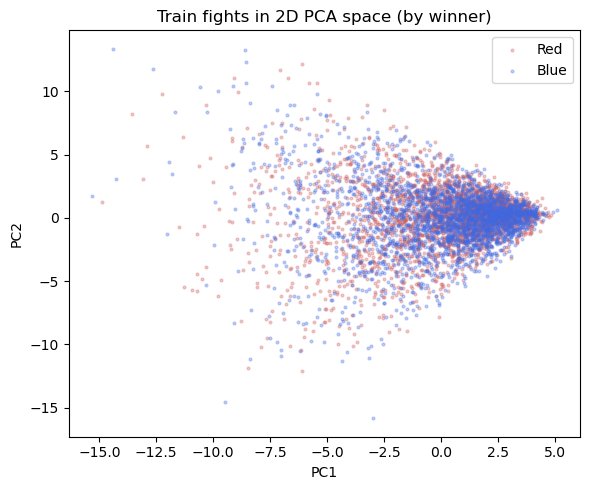

In [6]:
# 2D PCA scatter coloured by winner
p2 = PCA(n_components=2).fit(Xtr); Z = p2.transform(Xtr)
fig, ax = plt.subplots(figsize=(6,5))
for cls, c in [('Red','indianred'), ('Blue','royalblue')]:
    mask = collapse_winner(ytr) == cls
    ax.scatter(Z[mask,0], Z[mask,1], s=4, alpha=0.3, color=c, label=cls)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.set_title('Train fights in 2D PCA space (by winner)')
plt.tight_layout(); save_fig('pca_2d'); plt.show()

## 3. Discussion & conclusions
See report Sections 8 and 9. Headline: best models reach ~0.63 winner accuracy (in the published ceiling); SAMME ties LDA, so the added complexity does not pay off here; the market still edges us on log-loss but we are close; QDA/kNN are weak in high dimensions, and the ablation above shows whether DR recovers them.